#Q1 - Supervised Learning (Heart Disease Prediction)

1. Data Loading and Inspection

In [1]:
#importing libraries
import pandas as pd

#loading dataset
df = pd.read_csv('../data/q1_heart_disease.csv')

#printing shape
print("Shape of dataset:", df.shape)

#printing datatypes
print("\nData types:\n", df.dtypes)

#checking missing values
print("\nMissing values:\n", df.isnull().sum())

#showing first 5 rows
df.head()

Shape of dataset: (800, 12)

Data types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


2. Exploratory Data Analysis

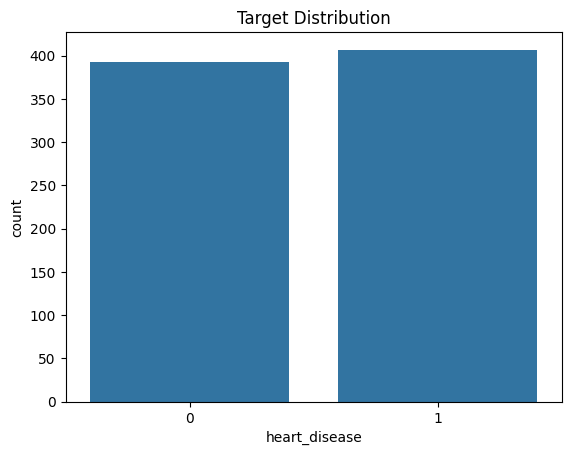

In [2]:
#importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#plot target distribution
sns.countplot(x='heart_disease', data=df)
plt.title('Target Distribution')
plt.show()

Observation:

This plot shows how many patients have heart disease and how many do not.

both classes are almost equal, dataset is balanced.

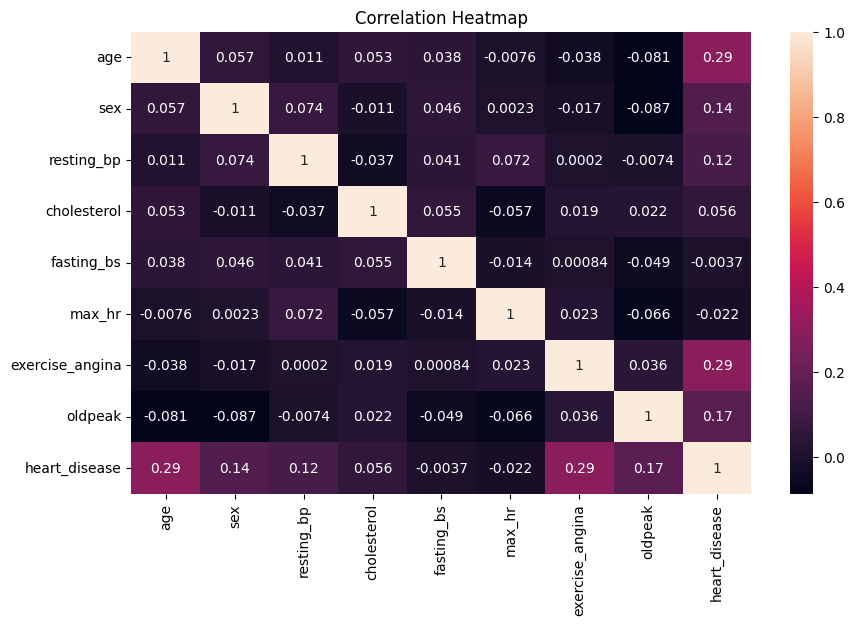

In [3]:
#correlation heatmap for numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

Observation:

This heatmap shows relationship between different features.

We can see which features are strongly related to heart_disease.  
Higher values mean stronger relation.

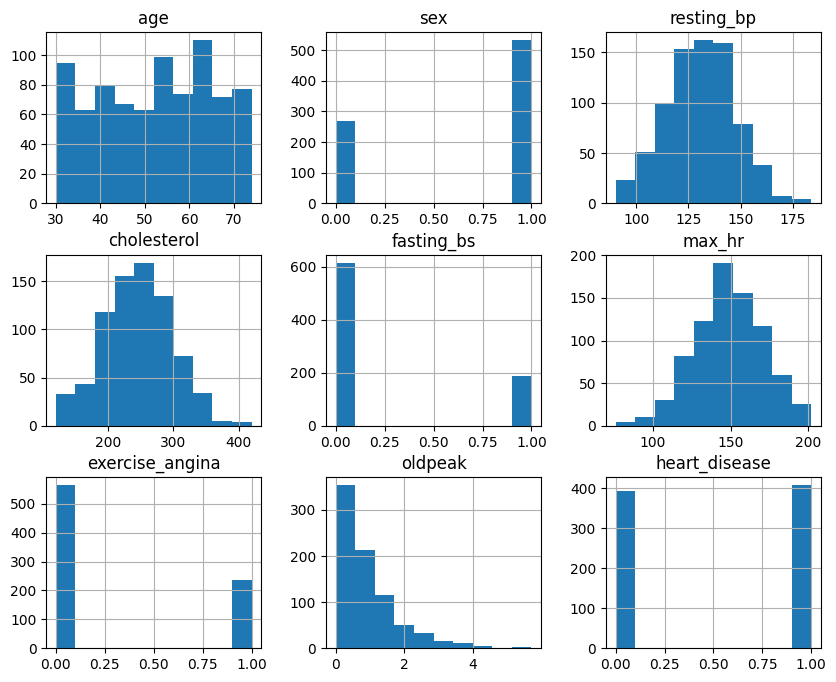

In [4]:
#distribution of numerical features
df.hist(figsize=(10,8))
plt.show()

Observation:

This shows distribution of features like age, cholesterol, etc.

We can understand:
- range of values
- skewness of data
- possible outliers

3. Data Preprocessing

Handling Missing Values

We are filling missing values using median.

Reason: Median is better than mean when outliers are present in data.

In [5]:
#filling missing values using median
df = df.fillna(df.median(numeric_only=True))

In [6]:
#separating features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

Encoding Categorical Variables

We are using one-hot encoding to convert categorical data into numerical form.

In [7]:
#applying one-hot encoding
X = pd.get_dummies(X, drop_first=True)

Feature Scaling

We are using StandardScaler to scale features.

This helps models perform better by normalizing values.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#scaling features
X_scaled = scaler.fit_transform(X)

Train-Test Split

Splitting data into training and testing sets.

- stratify=y - keeps class balance same
- random_state=42 - for reproducibility

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

4. Model Training

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#creating models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

#training models
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

5. Model Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    print("\nModel:", name)
    
    #predicting
    y_pred = model.predict(X_test)
    
    #confusion matrix
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    
    #classification report
    print("Classification Report:\n", classification_report(y_test, y_pred))


Model: Decision Tree
Confusion Matrix:
 [[56 23]
 [25 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


Model: Random Forest
Confusion Matrix:
 [[61 18]
 [15 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Model: Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77  

Model Comparison and Best Model Selection

evaluated three models: Decision Tree, Random Forest, and Gradient Boosting using precision, recall, and F1-score.

Decision Tree:
- Accuracy: 70%
- F1-score: 0.70
- Performance is moderate, but it makes more mistakes compared to other models.

Random Forest:
- Accuracy: 79%
- F1-score: 0.79–0.80
- It has the highest precision and recall among all models.
- Confusion matrix also shows fewer false predictions.

Gradient Boosting:
- Accuracy: 77%
- F1-score: 0.77
- Performance is good but slightly lower than Random Forest.

Final Conclusion:
Random Forest is the best performing model because:
- It has the highest F1-score
- It gives better classification for both classes (0 and 1)
- It has fewer false positives and false negatives compared to other models

Random Forest is selected as the final model.

6. Hyperparameter Tuning

In [12]:
from sklearn.model_selection import GridSearchCV

#tuning Random Forest
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, None]
}

grid = GridSearchCV(rf, param_grid, cv=3)

#training grid search
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


The best hyperparameters found for the Random Forest model are:

- max_depth = 5  
- n_estimators = 100  

This means the model performs best when:
- The number of trees is 100
- Each tree has a maximum depth of 5

In [13]:
#evaluating tuned model
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nTuned Model Performance")

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Tuned Model Performance
Confusion Matrix:
 [[58 21]
 [16 65]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.73      0.76        79
           1       0.76      0.80      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



Tuned Model Performance

After applying hyperparameter tuning, the Random Forest model achieved:
- Accuracy: 77%
- Precision:
  - Class 0: 0.78
  - Class 1: 0.76
- Recall:
  - Class 0: 0.73
  - Class 1: 0.80
- F1-score:
  - Class 0: 0.76
  - Class 1: 0.78


Confusion Matrix Interpretation:
- True Negatives (0 predicted correctly): 58  
- False Positives (0 predicted as 1): 21  
- False Negatives (1 predicted as 0): 16  
- True Positives (1 predicted correctly): 65  



Observation:
- The model performs reasonably well for both classes.
- Recall for class 1 (heart disease) is 0.80, which is good because detecting disease is important.
- However, there are still some false negatives (16 cases), which means some disease cases are missed.

Comparison with Untuned Model:
- Untuned model had better accuracy (79%) and slightly better F1-score.
- Tuned model accuracy reduced to 77%.

Final Conclusion:
Hyperparameter tuning did not improve performance in this case.
The untuned Random Forest model remains the best choice because it provides:
- Higher accuracy
- Better overall F1-score